<a href="https://colab.research.google.com/github/santhiya2313-spec/MachineLearning-Lab/blob/main/ML_Day10New.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [46]:
(X_train, y_train), (_, _) = mnist.load_data()

X_train = X_train.astype("float32")
X_train = (X_train - 127.5) / 127.5
X_train = np.expand_dims(X_train, -1)

print(X_train.shape)
print(y_train.shape)

(60000, 28, 28, 1)
(60000,)


In [47]:
BATCH_SIZE = 128

dataset = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train)
)

dataset = dataset.shuffle(10000)
dataset = dataset.batch(BATCH_SIZE, drop_remainder=True)
dataset = dataset.prefetch(tf.data.AUTOTUNE)

print("Dataset Ready")

Dataset Ready


In [48]:
def build_generator():

    noise = layers.Input(shape=(100,))
    label = layers.Input(shape=(1,))

    label_embedding = layers.Embedding(10, 50)(label)
    label_embedding = layers.Flatten()(label_embedding)

    x = layers.Concatenate()([noise, label_embedding])

    x = layers.Dense(7 * 7 * 256, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Reshape((7, 7, 256))(x)

    x = layers.Conv2DTranspose(
        128, 4, strides=2, padding="same",
        use_bias=False
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2DTranspose(
        64, 4, strides=2, padding="same",
        use_bias=False
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    output = layers.Conv2D(
        1, 7, padding="same",
        activation="tanh"
    )(x)

    return tf.keras.Model(
        [noise, label],
        output,
        name="Generator"
    )


generator = build_generator()

generator.summary()

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 50)     │        500 │ input_layer_5[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 50)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 150)       │          0 │ input_layer_4[0]… │
│ (Concatenate)       │                   │            │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 12544)     │  1,881,600 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 12544)     │     50,176 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_10      │ (None, 12544)     │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 7, 7, 256) │          0 │ leaky_re_lu_10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, 14, 14,    │    524,288 │ reshape_2[0][0]   │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_11      │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_5  │ (None, 28, 28,    │    131,072 │ leaky_re_lu_11[0… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        256 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_12      │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 28, 28, 1) │      3,137 │ leaky_re_lu_12[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,591,541 (9.89 MB)

 Trainable params: 2,566,069 (9.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

In [49]:
def build_discriminator():

    image = layers.Input(shape=(28, 28, 1))
    label = layers.Input(shape=(1,))

    label_embedding = layers.Embedding(
        10, 28 * 28
    )(label)

    label_embedding = layers.Flatten()(label_embedding)

    label_embedding = layers.Reshape(
        (28, 28, 1)
    )(label_embedding)

    x = layers.Concatenate()(
        [image, label_embedding]
    )

    x = layers.Conv2D(
        64, 4, strides=2, padding="same"
    )(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(
        128, 4, strides=2, padding="same"
    )(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Flatten()(x)

    output = layers.Dense(1)(x)

    return tf.keras.Model(
        [image, label],
        output,
        name="Discriminator"
    )


discriminator = build_discriminator()

discriminator.summary()

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 784)    │      7,840 │ input_layer_7[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 784)       │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_6       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 28, 28, 1) │          0 │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 28, 28, 2) │          0 │ input_layer_6[0]… │
│ (Concatenate)       │                   │            │ reshape_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 14, 14,    │      2,112 │ concatenate_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_13      │ (None, 14, 14,    │          0 │ conv2d_7[0][0]    │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 14, 14,    │          0 │ leaky_re_lu_13[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 7, 7, 128) │    131,200 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_14      │ (None, 7, 7, 128) │          0 │ conv2d_8[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 7, 7, 128) │          0 │ leaky_re_lu_14[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 6272)      │          0 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │      6,273 │ flatten_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 147,425 (575.88 KB)

 Trainable params: 147,425 (575.88 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
loss_function = tf.keras.losses.BinaryCrossentropy(
    from_logits=True
)

g_optimizer = tf.keras.optimizers.Adam(
    0.0002, beta_1=0.5
)

d_optimizer = tf.keras.optimizers.Adam(
    0.0002, beta_1=0.5
)

print("Ready")

Ready


In [51]:
@tf.function
def train_step(real_images, real_labels):

    noise = tf.random.normal(
        [BATCH_SIZE, 100]
    )

    fake_labels = tf.random.uniform(
        [BATCH_SIZE, 1],
        minval=0,
        maxval=10,
        dtype=tf.int32
    )

    with tf.GradientTape() as g_tape, \
         tf.GradientTape() as d_tape:

        fake_images = generator(
            [noise, fake_labels],
            training=True
        )

        real_output = discriminator(
            [real_images, real_labels],
            training=True
        )

        fake_output = discriminator(
            [fake_images, fake_labels],
            training=True
        )

        g_loss = loss_function(
            tf.ones_like(fake_output),
            fake_output
        )

        real_loss = loss_function(
            tf.ones_like(real_output) * 0.9,
            real_output
        )

        fake_loss = loss_function(
            tf.zeros_like(fake_output),
            fake_output
        )

        d_loss = real_loss + fake_loss

    g_gradients = g_tape.gradient(
        g_loss,
        generator.trainable_variables
    )

    d_gradients = d_tape.gradient(
        d_loss,
        discriminator.trainable_variables
    )

    g_optimizer.apply_gradients(
        zip(
            g_gradients,
            generator.trainable_variables
        )
    )

    d_optimizer.apply_gradients(
        zip(
            d_gradients,
            discriminator.trainable_variables
        )
    )

    return g_loss, d_loss

In [55]:
EPOCHS = 20

for epoch in range(EPOCHS):

    for images, labels in dataset:

        g_loss, d_loss = train_step(
            images,
            labels
        )

    print(
        f"Epoch {epoch + 1}/{EPOCHS} "
        f"| G Loss: {g_loss:.4f} "
        f"| D Loss: {d_loss:.4f}"
    )

Epoch 1/20 | G Loss: 0.8316 | D Loss: 1.3097
Epoch 2/20 | G Loss: 0.8795 | D Loss: 1.3477
Epoch 3/20 | G Loss: 0.7940 | D Loss: 1.3564
Epoch 4/20 | G Loss: 0.8047 | D Loss: 1.3581
Epoch 5/20 | G Loss: 0.7939 | D Loss: 1.3186
Epoch 6/20 | G Loss: 0.8007 | D Loss: 1.3584
Epoch 7/20 | G Loss: 0.9062 | D Loss: 1.3798
Epoch 8/20 | G Loss: 0.7852 | D Loss: 1.3553
Epoch 9/20 | G Loss: 0.8376 | D Loss: 1.3525
Epoch 10/20 | G Loss: 0.8283 | D Loss: 1.3502
Epoch 11/20 | G Loss: 0.7687 | D Loss: 1.3542
Epoch 12/20 | G Loss: 0.7860 | D Loss: 1.3787
Epoch 13/20 | G Loss: 0.8030 | D Loss: 1.3489
Epoch 14/20 | G Loss: 0.8581 | D Loss: 1.3652
Epoch 15/20 | G Loss: 0.7766 | D Loss: 1.3533
Epoch 16/20 | G Loss: 0.7637 | D Loss: 1.3817
Epoch 17/20 | G Loss: 0.8020 | D Loss: 1.3689
Epoch 18/20 | G Loss: 0.7484 | D Loss: 1.3940
Epoch 19/20 | G Loss: 0.7627 | D Loss: 1.3845
Epoch 20/20 | G Loss: 0.8492 | D Loss: 1.3628


In [56]:
noise = tf.random.normal([10, 100])

labels = tf.range(10)
labels = tf.reshape(labels, (10, 1))

generated_images = generator(
    [noise, labels],
    training=False
)

generated_images = generated_images.numpy()

print(
    "Generated Images Shape:",
    generated_images.shape
)

Generated Images Shape: (10, 28, 28, 1)


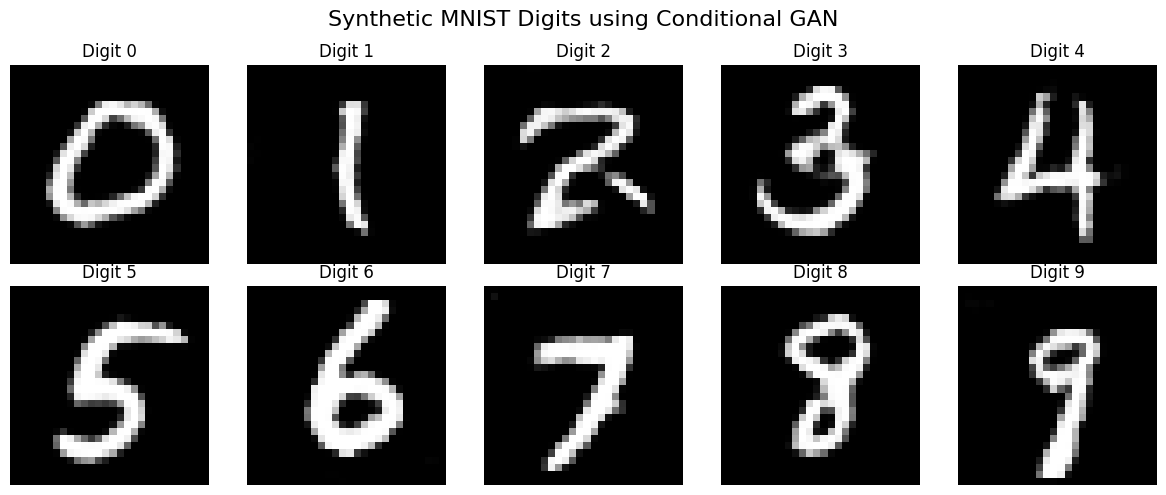

In [57]:
plt.figure(figsize=(12, 5))

for i in range(10):

    image = (generated_images[i] + 1) / 2

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        image.squeeze(),
        cmap="gray"
    )

    plt.title(f"Digit {i}")
    plt.axis("off")

plt.suptitle(
    "Synthetic MNIST Digits using Conditional GAN",
    fontsize=16
)

plt.tight_layout()
plt.show()